Baseline model, XGBoost with metadata

In [21]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [22]:
from google.colab import drive
drive.mount('/content/drive')

train = pd.read_csv("/content/drive/MyDrive/AMLProject/train.csv")
val = pd.read_csv("/content/drive/MyDrive/AMLProject/val.csv")
test = pd.read_csv("/content/drive/MyDrive/AMLProject/test.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
CATEGORICAL_COLS = ["Category", "Time of Day", "post_day"]
NUMERIC_COLS = ["title_len", "ocr_len", "post_hour", "account_age_days"]
TARGET = "is_viral"

In [24]:
encoders = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    val[col] = le.transform(val[col])
    test[col] = le.transform(test[col])
    encoders[col] = le

In [25]:
for df in [train, val, test]:
    df["log_total_karma"]   = np.log1p(df["Total Karma"].clip(lower=0))
    df["log_comment_karma"] = np.log1p(df["Comment Karma"].clip(lower=0))

FEATURE_COLS = CATEGORICAL_COLS + NUMERIC_COLS + ["log_total_karma", "log_comment_karma"]

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_val, y_val = val[FEATURE_COLS], val[TARGET]
X_test, y_test = test[FEATURE_COLS], test[TARGET]


In [26]:
FEATURE_COLS

['Category',
 'Time of Day',
 'post_day',
 'title_len',
 'ocr_len',
 'post_hour',
 'account_age_days',
 'log_total_karma',
 'log_comment_karma']

In [27]:
def evaluate(model, X, y, split_name):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:, 1]
    print(f"\n{'='*55}")
    print(f"  {split_name}")
    print(f"{'='*55}")
    print(f"Accuracy: {accuracy_score(y, preds):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y, probs):.4f}")
    print(f"F1 (macro): {f1_score(y, preds, average='macro'):.4f}")
    print(f"F1 (viral): {f1_score(y, preds, pos_label=1):.4f}")

# Baseline XGBoost

In [28]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")

Class imbalance ratio (scale_pos_weight): 3.00


In [29]:
baseline = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)

baseline.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [30]:

evaluate(baseline, X_train, y_train, "Train")
evaluate(baseline, X_val,   y_val,   "Validation")
evaluate(baseline, X_test,  y_test,  "Test")


  Train
Accuracy: 0.9662
ROC-AUC: 0.9981
F1 (macro): 0.9568
F1 (viral): 0.9365

  Validation
Accuracy: 0.6860
ROC-AUC: 0.6804
F1 (macro): 0.6071
F1 (viral): 0.4311

  Test
Accuracy: 0.6671
ROC-AUC: 0.6610
F1 (macro): 0.5906
F1 (viral): 0.4136


# Hyperparameter tunning

In [31]:
param_dist = {
    "n_estimators" : [200, 400, 600, 800],
    "max_depth" : [3, 4, 5, 6, 8],
    "learning_rate" : [0.01, 0.05, 0.1, 0.2],
    "subsample" : [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree" : [0.5, 0.6, 0.7, 0.8, 1.0],
    "min_child_weight" : [1, 3, 5, 7],
    "gamma" : [0, 0.1, 0.3, 0.5, 1.0],
    "reg_alpha" : [0, 0.01, 0.1, 1.0],
    "reg_lambda" : [0.5, 1.0, 2.0, 5.0],
}

xgb_tuner = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)

search = RandomizedSearchCV(
    xgb_tuner,
    param_distributions=param_dist,
    n_iter=50,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

search.fit(X_train, y_train)

print(f"\nBest CV ROC-AUC: {search.best_score_}")
print(f"Best params:\n{search.best_params_}")

best_model = search.best_estimator_

Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best CV ROC-AUC: 0.6706954762385684
Best params:
{'subsample': 0.6, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.7}


# Tuned Result

In [32]:
evaluate(best_model, X_train, y_train, "Train")
evaluate(best_model, X_val, y_val, "Validation")
evaluate(best_model, X_test,  y_test, "Test")


  Train
Accuracy: 0.6538
ROC-AUC: 0.7719
F1 (macro): 0.6250
F1 (viral): 0.5209

  Validation
Accuracy: 0.6196
ROC-AUC: 0.6992
F1 (macro): 0.5933
F1 (viral): 0.4898

  Test
Accuracy: 0.5912
ROC-AUC: 0.6745
F1 (macro): 0.5655
F1 (viral): 0.4599


# Plots

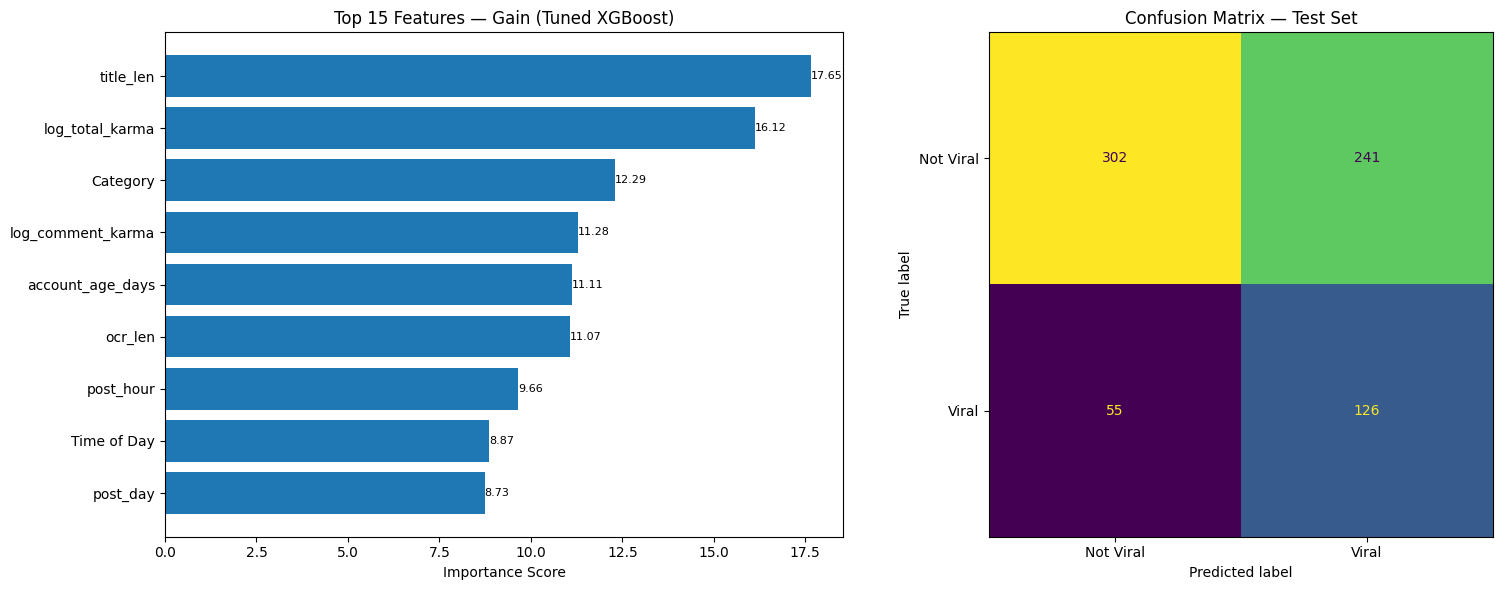

In [33]:
importance_dict = best_model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    "feature": list(importance_dict.keys()),
    "importance": list(importance_dict.values())
}).sort_values("importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top15 = importance_df.head(15)
axes[0].barh(top15["feature"][::-1], top15["importance"][::-1])
axes[0].set_xlabel("Importance Score")
axes[0].set_title("Top 15 Features — Gain (Tuned XGBoost)")
for i, v in enumerate(top15["importance"][::-1]):
    axes[0].text(v + 0.0001, i, f"{v:.2f}", va="center", fontsize=8)

# Confusion Matrix
test_preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not Viral", "Viral"])
disp.plot(ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix — Test Set")

plt.tight_layout()
plt.show()

# Summary

In [34]:
rows = []
for model_name, model in [("Baseline", baseline), ("Tuned", best_model)]:
    for split_name, X, y in [("Train", X_train, y_train),
                               ("Val",   X_val,   y_val),
                               ("Test",  X_test,  y_test)]:
        preds = model.predict(X)
        probs = model.predict_proba(X)[:, 1]
        rows.append({
            "Model" : model_name,
            "Split" : split_name,
            "Accuracy": round(accuracy_score(y, preds), 4),
            "ROC-AUC" : round(roc_auc_score(y, probs),  4),
            "F1-macro": round(f1_score(y, preds, average="macro"), 4),
            "F1-viral": round(f1_score(y, preds, pos_label=1), 4),
        })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

   Model Split  Accuracy  ROC-AUC  F1-macro  F1-viral
Baseline Train    0.9662   0.9981    0.9568    0.9365
Baseline   Val    0.6860   0.6804    0.6071    0.4311
Baseline  Test    0.6671   0.6610    0.5906    0.4136
   Tuned Train    0.6538   0.7719    0.6250    0.5209
   Tuned   Val    0.6196   0.6992    0.5933    0.4898
   Tuned  Test    0.5912   0.6745    0.5655    0.4599
